# Max membership principle
Atau biasa dikenal dengan: <i>the height method</i>

$$ μC(x*) ≥ μC(x), ∀x ∈ X

Simplenya gini, Nilai keanggotaan dari x∗ pada himpunan fuzzy C lebih besar atau sama dengan nilai keanggotaan dari x pada C, untuk semua dalam semesta X

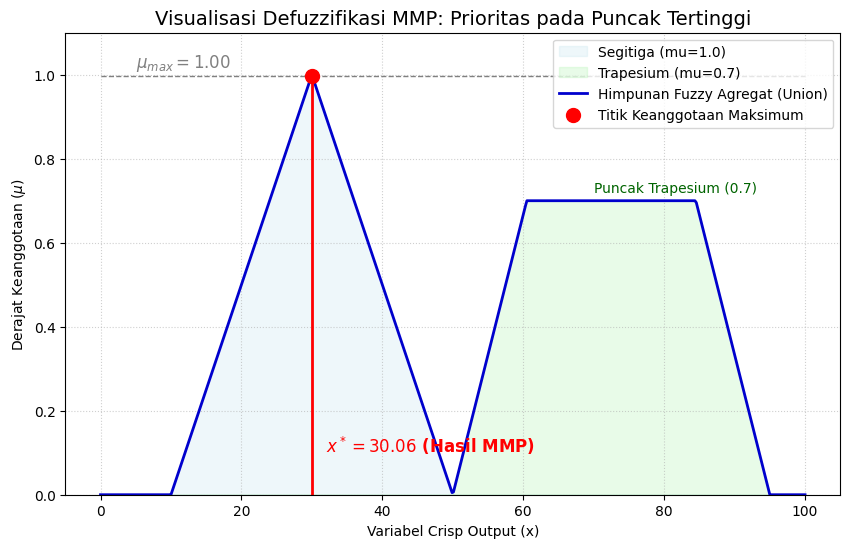

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Definisikan Himpunan Fuzzy Output ---

# Domain diskursus (variabel output, misalnya Tingkat Risiko 0-100)
x = np.linspace(0, 100, 500)

# Fungsi Keanggotaan Segitiga
def triangular_mf(x, a, m, b):
    # a: batas kiri, m: puncak, b: batas kanan
    return np.maximum(0, np.minimum((x - a) / (m - a), (b - x) / (b - m)))

# Fungsi Keanggotaan Trapesium
def trapezoidal_mf(x, a, b, c, d):
    # a, d: batas alas, b, c: batas puncak datar
    return np.maximum(0, np.minimum(np.minimum((x - a) / (b - a), 1), (d - x) / (d - c)))

# Himpunan Fuzzy A (Segitiga Tinggi) - Puncak di x=30, mu=1.0
mu_A = triangular_mf(x, 10, 30, 50)

# Himpunan Fuzzy B (Trapesium Rendah) - Puncak datar antara x=65 dan x=80, mu=0.7
mu_B_full = trapezoidal_mf(x, 50, 65, 80, 95)
# Sesuaikan ketinggian trapesium menjadi 0.7
mu_B = np.minimum(mu_B_full, 0.7) 

# Himpunan Output Teragregasi (Union/MAX)
mu_total = np.maximum(mu_A, mu_B)

# --- 2. Terapkan Max Membership Principle (MMP) ---

# Temukan Derajat Keanggotaan Maksimum (mu_max) dari gabungan
mu_max = np.max(mu_total)

# Temukan Indeks Posisi di mana mu_total mencapai maksimum
indices_max = np.where(mu_total == mu_max)
# Karena kurva Segitiga yang menang, kita ambil indeks puncaknya (Smallest of Maximum)
x_star_index = indices_max[0][0] 
x_star = x[x_star_index]

# --- 3. Visualisasi dengan Matplotlib ---

plt.figure(figsize=(10, 6))

# Plot Himpunan Fuzzy Individu (Opsional, untuk konteks)
plt.fill_between(x, mu_A, 0, alpha=0.2, color='lightblue', label='Segitiga (mu=1.0)')
plt.fill_between(x, mu_B, 0, alpha=0.2, color='lightgreen', label='Trapesium (mu=0.7)')

# Plot Kurva Himpunan Fuzzy Total (Agregasi)
plt.plot(x, mu_total, label='Himpunan Fuzzy Agregat (Union)', color='mediumblue', linewidth=2)

# Tandai Titik Maksimum (Puncak)
plt.scatter(x_star, mu_max, color='red', s=100, zorder=5, label='Titik Keanggotaan Maksimum')

# Garis Horizontal (Level mu_max)
plt.hlines(mu_max, 0, 100, color='grey', linestyle='--', linewidth=1)

# Garis Vertikal (Hasil Defuzzifikasi x*)
plt.vlines(x_star, 0, mu_max, color='red', linestyle='-', linewidth=2)

# Tambahkan Teks Hasil Defuzzifikasi
plt.text(x_star + 2, 0.1, f'$x^* = {x_star:.2f}$ (Hasil MMP)', 
         color='red', fontsize=12, fontweight='bold')
plt.text(5, mu_max + 0.02, f'$\mu_{{max}} = {mu_max:.2f}$', 
         color='grey', fontsize=12)
plt.text(70, 0.7 + 0.02, 'Puncak Trapesium (0.7)', 
         color='darkgreen', fontsize=10)


# Label dan Judul
plt.title('Visualisasi Defuzzifikasi MMP: Prioritas pada Puncak Tertinggi', fontsize=14)
plt.xlabel('Variabel Crisp Output (x)')
plt.ylabel('Derajat Keanggotaan ($\mu$)')
plt.ylim(0, 1.1)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.show()

Well sebenernya MMP ini ada kelemahannya, yaitu nilai puncaknya (maksimumnya) itu unique atau ya hanya ada 1. Gimana Kalau banyak? (Let say kita bermain di trapozoid atau bentuk lainnya yang puncaknya > 1)

Disinilah fungsi dari variasi-variasi MMP berguna.
<b>
- Smallest of Maximum (SoM)
- Largest of Maximum (LoM)
- Middle of Maximum (MoM)
</b>

Karena pada akhirnya maksud dari "titik puncak" itu relatif

## 1. Smallest of Maximum (SoM)
mengambil nilai x terkecil yang mencapai puncak tertinggi dari himpunan fuzzy output

$$
x^* = \min \{ x \mid \mu_C(x) = h(C) \}
$$


artinya:
1. Pertama, kita cari derajat keanggotaan maksimum ($\mu_{\mathrm{max}}$) dari himpunan fuzzy output $C$. Dalam notasi yang kita sebut $h(C)$ (dibaca ketinggian atau height dari himpunan C).
$$
h(C) = \max\limits_{x} \mu_C(x)
$$
Merpakan titik tertinggi pada kurva himpunan fuzzy.

2. kita identifikasi semua nilai x yang mencapat ketinggian maksimum, makanya ditulis:

$$
\mu_C(x) = h(C)
$$
Pokoknya identifikasi semuanya dulu

3. terakhir, dari semua nilai x yang ditemukan pada langkah 2, pilih nilai x yang terkecil (minimum).

### 🌻 BTW
kalo masih agak bingung maksud dari maksudnya sumbu X dan nilai membership apa, chill. intinya:
- **Nilai X (atau nanti pas di graph jadi sumbu x)** adalah nilai crisp (jelas, non-fuzzy) intinya Variabel output yang memiliki nilai numerik spesifik.

Contoh, suhu, X nanti adalah 25∘C, 30∘C,35∘C.

- **Nilai Membership ($μ$, nanti di graph jadi sumbu y)** adalah derajat keanggotaan suatu nilai X terhadap suatu himpunan fuzzy (misalnya "panas", "adem", "dingin"). Nilai dari $μ$ selalu berada dalam rentang 0 sampai 1

In short "tingkat kebenaran atau keyakinan sistem bahwa suatu nilai X termasuk dalam himpunan fuzzy tertentu"

Contoh
- $μ$=0: Sama sekali tidak termasuk dalam himpunan tersebut (benar-benar salah).

- $μ$=1: Sepenuhnya termasuk dalam himpunan tersebut (sepenuhnya benar).

- $μ$=0.6: Sebagian (60%) termasuk dalam himpunan tersebut.

## 2. Largest of Maximum (LoM)
Nilai x terbesar di antara semua nilai yang mencapai $μ$ max

$$
x^* = \max \{ x \mid \mu_C(x) = h(C) \}
$$

Hmm, ya intinya sama kayak sebelumnya, bedanya sebelumnya pakai $min$ kalau LoM pakai $max$


## 3. Mean of Maximum (MoM)
Tujuan MoM adalah mengambil nilai rata-rata (mean) dari seluruh rentang nilai X yang mencapai derajat keanggotaan maksimum ($\mu_{\text{max}}$) 

$$
x^* = \frac{1}{|\{x \mid \mu_C(x) = h(C)\}|} 
\sum_{x \,:\, \mu_C(x) = h(C)} x
$$


Agak aneh? tapi intinya 
$$
\text{Rata-rata (MoM)} = 
\frac{\text{Jumlah semua } x \text{ yang maksimum}}
{\text{Banyaknya } x \text{ yang maksimum}}
$$




### Ini visualisasinya

In [14]:
import numpy as np
import skfuzzy as fuzz
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# [0, 10]
delta = 0.001
start = 0
stop = 10 + delta
step = 0.5
x = np.arange(start, stop + delta, step)

# Triangular membership function
x1 = np.arange(0, 5 + delta, step)
trimf = fuzz.trimf(x1, [0, 2.5, 5])

# Trapezoidal membership function
x2 = np.arange(4, 10 + delta, step)
trapmf = fuzz.trapmf(x2, [4, 6, 8, 10])

# fuzzy logic
tri_not = fuzz.fuzzy_not(trimf)
trap_not = fuzz.fuzzy_not(trapmf)
x3, tri_trap_and = fuzz.fuzzy_and(x1, trimf, x2, trapmf)
x3, tri_trap_or = fuzz.fuzzy_or(x1, trimf, x2, trapmf)

# Defuzzify
mom_x = fuzz.defuzz(x3, tri_trap_or, "mom")
mom_y = fuzz.interp_membership(x3, tri_trap_or, mom_x)
som_x = fuzz.defuzz(x3, tri_trap_or, "som")
som_y = fuzz.interp_membership(x3, tri_trap_or, som_x)
lom_x = fuzz.defuzz(x3, tri_trap_or, "lom")
lom_y = fuzz.interp_membership(x3, tri_trap_or, lom_x)

fig = make_subplots(rows=1, cols=1)

# Add traces for all plots
fig.add_trace(go.Scatter(x=x1, y=trimf, name="Triangle", mode="lines+markers", marker=dict(symbol="circle"), visible="legendonly"))
fig.add_trace(go.Scatter(x=x2, y=trapmf, name="Trapezoidal", mode="lines+markers", marker=dict(symbol="circle"), visible="legendonly"))
fig.add_trace(go.Scatter(x=x1, y=tri_not, name="Fuzzy NOT Triangle", mode="lines+markers", marker=dict(symbol="x"), visible="legendonly"))
fig.add_trace(go.Scatter(x=x2, y=trap_not, name="Fuzzy NOT Trapezoidal", mode="lines+markers", marker=dict(symbol="x"), visible="legendonly"))
fig.add_trace(go.Scatter(x=x3, y=tri_trap_and, name="Fuzzy AND", mode="lines+markers", marker=dict(symbol="triangle-up"), visible="legendonly"))
fig.add_trace(go.Scatter(x=x3, y=tri_trap_or, name="Fuzzy OR", mode="lines+markers", marker=dict(symbol="triangle-down")))

# Add defuzzification lines
fig.add_trace(go.Scatter(x=[mom_x, mom_x], y=[0, mom_y], name="mom", mode="lines"))
fig.add_trace(go.Scatter(x=[som_x, som_x], y=[0, som_y], name="som", mode="lines"))
fig.add_trace(go.Scatter(x=[lom_x, lom_x], y=[0, lom_y], name="lom", mode="lines"))

fig.update_layout(
    title="Defuzzification Plot",
    xaxis_title="X",
    yaxis_title="Membership",
    width=800,
    height=500,
    updatemenus=[
        dict(
            type="dropdown",
            direction="down",
            buttons=list([
                dict(
                    args=[{"visible": [False]*5 + [True]*6}],
                    label="Defuzzification",
                    method="update"
                ),
                dict(
                    args=[{"visible": [True]*2 + [False]*9}],
                    label="Membership Functions",
                    method="update"
                ),
                dict(
                    args=[{"visible": [False]*2 + [True]*4 + [False]*5}],
                    label="Fuzzy Operations",
                    method="update"
                ),
                dict(
                    args=[{"visible": [True]*11}],
                    label="Show All",
                    method="update"
                )
            ]),
        )
    ]
)

fig.show()